<a href="https://colab.research.google.com/github/VISHAL-1-3/Rohit-Sharma-Stats-Analysis/blob/main/rohit_stats.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   Unnamed: 0  Year  Innings  Runs  Balls  Outs   Avg    SR   HS  50  100  4s  \
0         0.0  2007        3    61     74     3  20.3  82.4   52   1    0   3   
1         1.0  2008       28   532    733    21  25.3  72.6   70   3    0  44   
2         2.0  2009        7   102    155     4  25.5  65.8   43   0    0   5   
3         3.0  2010       14   504    586    13  38.8  86.0  114   1    2  34   
4         4.0  2011       16   611    739    11  55.5  82.7   95   6    0  40   

   6s  Dot % Format  index  
0   1   47.3    ODI    NaN  
1   3   53.9    ODI    NaN  
2   1   52.3    ODI    NaN  
3   7   43.9    ODI    NaN  
4   9   45.6    ODI    NaN  
Index(['Unnamed: 0', 'Year', 'Innings', 'Runs', 'Balls', 'Outs', 'Avg', 'SR',
       'HS', '50', '100', '4s', '6s', 'Dot %', 'Format', 'index'],
      dtype='object')

===== FORMAT-WISE SUMMARY =====
   Format         Runs        Avg          SR  Impact_Score  Consistency_Index
0    ODI  1150.625000  45.943750   86.156250   4111.513125  

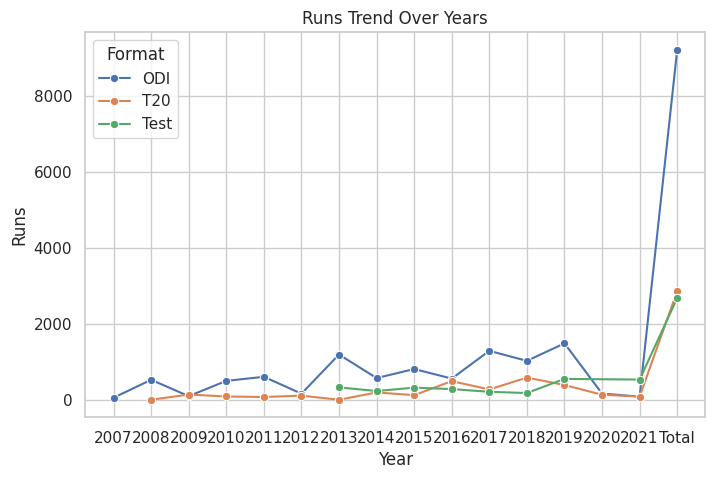

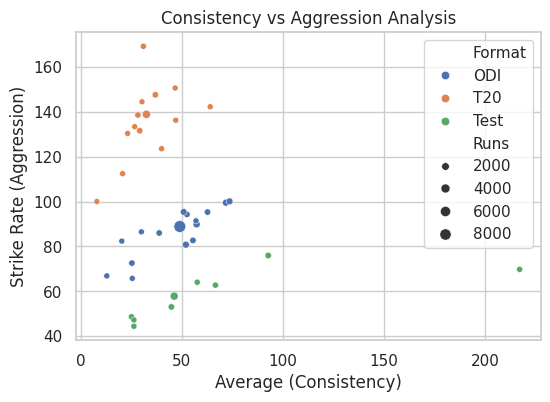

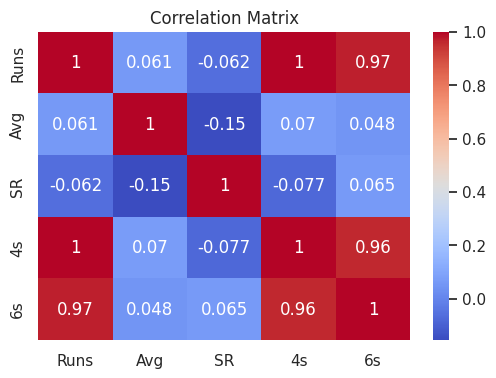


===== KEY INSIGHTS =====
Best Format (Highest Impact): T20
Most Consistent Format: Test
Most Aggressive Format: T20

===== STRATEGIC RECOMMENDATIONS =====
- T20 format should be leveraged for maximizing scoring impact through aggressive play
- Test format is best suited for stability-focused batting and long innings construction
- ODI format should be used as a balanced approach, combining controlled aggression with consistency
- Adapt batting strategy based on format-specific strengths rather than applying a uniform approach
- Monitor year-wise performance trends to identify peak phases and optimize role positioning


In [1]:
# ==============================
# 1. IMPORT LIBRARIES
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# ==============================
# 2. LOAD DATA
# ==============================
odi = pd.read_csv("ODI.csv")
t20 = pd.read_csv("T20.csv")
test = pd.read_csv("TEST.csv")

# Add format column
odi['Format'] = 'ODI'
t20['Format'] = 'T20'
test['Format'] = 'Test'

# Combine datasets
df = pd.concat([odi, t20, test], ignore_index=True)

print(df.head())
print(df.columns)

# ==============================
# 3. DATA CLEANING
# ==============================
# Convert numeric columns
cols = ['Runs', 'Balls', 'Outs', 'Avg', 'SR', '4s', '6s']
for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop missing values
df = df.dropna(subset=['Runs', 'Balls', 'Avg', 'SR'])

# Remove invalid rows
df = df[df['Balls'] > 0]

# ==============================
# 4. FEATURE ENGINEERING
# ==============================

# Impact Score (Normalized)
df['Impact_Score'] = df['Avg'] * df['SR']

# Boundary Runs
df['Boundary_Runs'] = df['4s']*4 + df['6s']*6

# Boundary %
df['Boundary_Percentage'] = (df['Boundary_Runs'] / df['Runs']) * 100

# Consistency Index
df['Consistency_Index'] = df['Runs'] / (df['Outs'] + 1)

# ==============================
# 5. FORMAT-WISE ANALYSIS
# ==============================
format_summary = df.groupby('Format').agg({
    'Runs': 'mean',
    'Avg': 'mean',
    'SR': 'mean',
    'Impact_Score': 'mean',
    'Consistency_Index': 'mean'
}).reset_index()

print("\n===== FORMAT-WISE SUMMARY =====\n", format_summary)

# ==============================
# 6. TREND ANALYSIS (VERY IMPORTANT)
# ==============================
plt.figure(figsize=(8,5))
sns.lineplot(x='Year', y='Runs', hue='Format', data=df, marker='o')
plt.title("Runs Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Runs")
plt.show()

# ==============================
# 7. CONSISTENCY VS AGGRESSION
# ==============================
plt.figure(figsize=(6,4))
sns.scatterplot(x='Avg', y='SR', hue='Format', size='Runs', data=df)
plt.title("Consistency vs Aggression Analysis")
plt.xlabel("Average (Consistency)")
plt.ylabel("Strike Rate (Aggression)")
plt.show()

# ==============================
# 8. CORRELATION ANALYSIS
# ==============================
corr = df[['Runs', 'Avg', 'SR', '4s', '6s']].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# ==============================
# 9. KEY INSIGHTS
# ==============================
print("\n===== KEY INSIGHTS =====")

best_format = format_summary.loc[format_summary['Impact_Score'].idxmax()]
print(f"Best Format (Highest Impact): {best_format['Format']}")

most_consistent = format_summary.loc[format_summary['Consistency_Index'].idxmax()]
print(f"Most Consistent Format: {most_consistent['Format']}")

most_aggressive = format_summary.loc[format_summary['SR'].idxmax()]
print(f"Most Aggressive Format: {most_aggressive['Format']}")



# ==============================
# 10. STRATEGIC RECOMMENDATIONS
# ==============================
print("\n===== STRATEGIC RECOMMENDATIONS =====")

print(f"- {best_format['Format']} format should be leveraged for maximizing scoring impact through aggressive play")
print(f"- {most_consistent['Format']} format is best suited for stability-focused batting and long innings construction")

print("- ODI format should be used as a balanced approach, combining controlled aggression with consistency")
print("- Adapt batting strategy based on format-specific strengths rather than applying a uniform approach")
print("- Monitor year-wise performance trends to identify peak phases and optimize role positioning")